In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [2]:
base = pd.read_csv("../data/시설 정보.csv")
facility = pd.read_csv("../data/시설 정보_바이오 제외.csv")
farm = pd.read_csv("../data/가축사육업.csv")
fire = pd.read_csv("../data/강원도_소방청_현황.csv")

In [3]:
# 바이오가스화시설 추출
bio = base[base['구분'].str.contains('바이오가스화시설')]
bio

,구분,시도,시군,시설명,도로명주소,위도,경도
0,바이오가스화시설,강원도,강릉시,강릉공공하수처리시설,강릉시 강변로 718,37.768119,128.940940
1,바이오가스화시설,강원도,춘천시,춘천공공하수처리시설,춘천시 영서로 2473,37.880234,127.710857
2,바이오가스화시설,강원도,원주시,원주공공하수처리장,원주시 호저로 227,37.390776,127.938717
3,바이오가스화시설,강원도,원주시,바이오메탄자동차 연료화시설,원주시 저금어지길 458,37.386235,127.901271
4,바이오가스화시설,강원도,속초시,강원 속초 음식물 하수병합처리시설,속초시 대포동 해오름길 86,38.179823,128.606487
5,바이오가스화시설,강원도,홍천군,홍천가축분뇨자원화시설,홍천군 북방면 소매곡길 12,37.707132,127.837152


#### 데이터 전처리 

In [4]:
# bio 데이터 GeoDataFrame으로 변환
gdf_bio = gpd.GeoDataFrame(bio, geometry=gpd.points_from_xy(bio['경도'], bio['위도']))

# facility 데이터 GeoDataFrame으로 변환
gdf_facility = gpd.GeoDataFrame(facility, geometry=gpd.points_from_xy(facility['경도'], facility['위도']))

# farm 데이터 GeoDataFrame으로 변환
gdf_farm = gpd.GeoDataFrame(farm, geometry=gpd.points_from_xy(farm['longitude'], farm['latitude']))

# fire 데이터 GeoDataFrame으로 변환
gdf_fire = gpd.GeoDataFrame(fire, geometry=gpd.points_from_xy(fire['lon'], fire['lat']))

# 좌표계 설정 (WGS84: EPSG 4326)
gdf_bio.set_crs(epsg=4326, inplace=True)
gdf_facility.set_crs(epsg=4326, inplace=True)
gdf_farm.set_crs(epsg=4326, inplace=True)
gdf_fire.set_crs(epsg=4326, inplace=True)

,순번,시도본부,X119안전센터명,주소,전화번호,FAX,lon,lat,address,latitude,longitude,geometry
0,543,강원,내곡119안전센터,강원도 강릉시 범일로 660,033-647-7119,043-740-7129,128.884667,37.744854,"660 beomil-ro, gangneung, gangwon-do, south korea",37.744854,128.884667,POINT (128.88467 37.74485)
1,544,강원,유천119안전센터,강원도 강릉시 선수촌로 64-28,033-645-0119,043-740-7159,128.872718,37.757132,"64-28 seonsuchon-ro, gangneung, gangwon-do, so...",37.757132,128.872718,POINT (128.87272 37.75713)
2,545,강원,옥계119안전센터,강원도 강릉시 옥계면 현내시장길 163,033-534-0119,043-740-7179,129.030160,37.602356,"163 hyeonnaesijang-gil, okgye-myeon, gangneung...",37.602356,129.030160,POINT (129.03016 37.60236)
3,546,강원,옥천119안전센터,강원도 강릉시 용지로 139,033-648-2119,043-730-1909,128.902188,37.761140,"139 yongji-ro, gangneung, gangwon-do, south korea",37.761140,128.902188,POINT (128.90219 37.76114)
4,547,강원,주문진119안전센터,강원도 강릉시 주문진읍 연주로 226,033-662-2119,043-730-1929,128.831596,37.873999,"226 yeonju-ro, yeongok-myeon, gangneung, gangw...",37.873999,128.831596,POINT (128.83160 37.87400)
...,...,...,...,...,...,...,...,...,...,...,...,...
67,610,강원,화천119안전센터,강원도 화천군 하남면 위라리 380번지,033-442-1119,041-356-0016,127.713453,38.097958,"380 wira-ri, hanam-myeon, hwacheon, gangwon-do...",38.097958,127.713453,POINT (127.71345 38.09796)
68,611,강원,둔내119안전센터,강원도 횡성군 둔내면 고원남로 42,033-342-1119,041-352-6319,128.212336,37.506513,"42 gowonnam-ro, dunnae-myeon, hoengseon, gangw...",37.506513,128.212336,POINT (128.21234 37.50651)
69,612,강원,우천119안전센터,강원도 횡성군 우천면 서동로 199,033-342-6119,041-362-7119,128.081323,37.441639,"seodong-ro, ucheon-myeon, hoengseong-gun, gang...",37.441639,128.081323,POINT (128.08132 37.44164)
70,613,강원,공근119안전센터,강원도 횡성군 공근면 영서로 130-5,033-344-3119,041-350-5349,127.955973,37.523884,"130-47 yeongseo-ro, gonggeun-myeon, hoengseon,...",37.523884,127.955973,POINT (127.95597 37.52388)


#### 공간적 상관관계 분석

In [5]:
from scipy.spatial import cKDTree

In [6]:
# bio 시설의 좌표
coords_bio = gdf_bio[['경도', '위도']].values

# bio 시설의 좌표
coords_facility = gdf_facility[['경도', '위도']].values

# farm 시설의 좌표
coords_farm = gdf_farm[['longitude', 'latitude']].values

# fire 시설의 좌표
coords_fire = gdf_fire[['lon', 'lat']].values

# KDTree 생성 : 각 시설의 좌표로 KD트리 생성. 
# KDTree란 ?  : 공간적으로 효율적인 데이터 구조로, 최근접 이웃 검색에 사용됨
kdtree_bio = cKDTree(coords_bio)
kdtree_facility = cKDTree(coords_facility)
kdtree_farm = cKDTree(coords_farm)
kdtree_fire = cKDTree(coords_fire)

# 최근접 이웃 거리 계산
# query 메서드를 사용하여 KD 트리를 활용하여 각 시설에서 가장 가까운 bio시설의 거리를 계산
# K 매개변수를 1로 설정하여 가장 가까운 이웃 하나만 검색함 
distances_facility, indices_facility = kdtree_bio.query(coords_facility, k=1)
distances_farm, indices_farm = kdtree_bio.query(coords_farm, k=1)
distances_fire, indices_fire = kdtree_bio.query(coords_fire, k=1)

# facility과 가장 가까운 bio 시설 거리 추가
gdf_facility['nearest_bio_distance'] = distances_facility

# farm과 가장 가까운 bio 시설 거리 추가
gdf_farm['nearest_bio_distance'] = distances_farm

# fire와 가장 가까운 bio 시설 거리 추가
gdf_fire['nearest_bio_distance'] = distances_fire

#### 거리 변환 (좌표 -> km)

In [7]:
def haversine(lon1, lat1, lon2, lat2):
    R = 6371.0  # 지구의 반지름 (km 단위)
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    distance = R * c
    return distance

In [11]:
# 가장 가까운 bio 시설의 경도, 위도 가져오기
nearest_facility_coords = coords_bio[indices_facility]

# 폐기물 시설에 대해 km 단위로 거리 계산
gdf_facility['nearest_bio_distance_km'] = [
    haversine(lon1, lat1, lon2, lat2)
    for (lon1, lat1), (lon2, lat2) in zip(coords_facility, nearest_facility_coords)
]

# 가장 가까운 bio 시설의 경도, 위도 가져오기
nearest_farm_coords = coords_bio[indices_farm]

# 폐기물 시설에 대해 km 단위로 거리 계산
gdf_farm['nearest_bio_distance_km'] = [
    haversine(lon1, lat1, lon2, lat2)
    for (lon1, lat1), (lon2, lat2) in zip(coords_farm, nearest_farm_coords)
]

# 가장 가까운 bio 시설의 경도, 위도 가져오기
nearest_fire_coords = coords_bio[indices_fire]

# 폐기물 시설에 대해 km 단위로 거리 계산
gdf_fire['nearest_bio_distance_km'] = [
    haversine(lon1, lat1, lon2, lat2)
    for (lon1, lat1), (lon2, lat2) in zip(coords_fire, nearest_fire_coords)
]

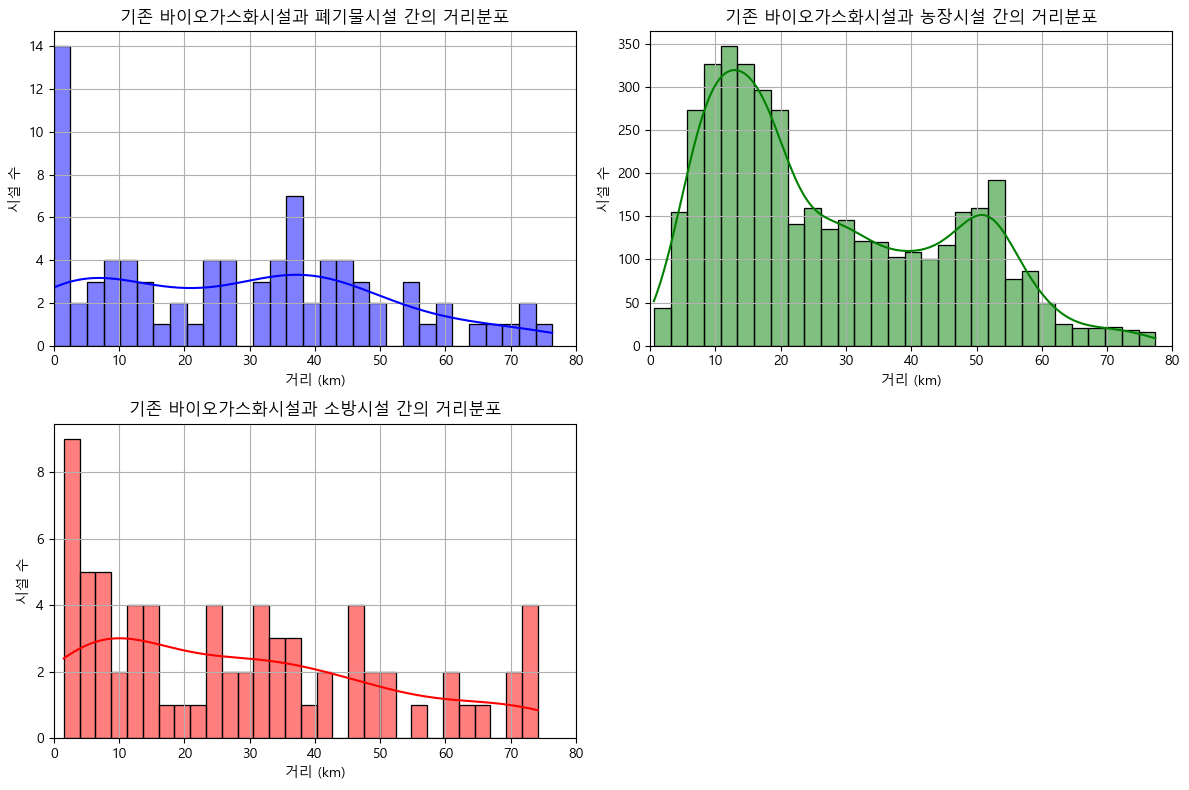

In [12]:
# 서브플롯 생성
fig, axes = plt.subplots(2, 2, figsize=(12, 8))  # 2x2 그리드

# 폐기물 처리 시설 거리 분포
sns.histplot(gdf_facility['nearest_bio_distance_km'], bins=30, kde=True, color='blue', ax=axes[0, 0])
axes[0, 0].set_title('기존 바이오가스화시설과 폐기물시설 간의 거리분포')
axes[0, 0].set_xlabel('거리 (km)')
axes[0, 0].set_ylabel('시설 수')
axes[0, 0].set_xlim(0, 80)
axes[0, 0].grid(True)

# 농장 시설 거리 분포
sns.histplot(gdf_farm['nearest_bio_distance_km'], bins=30, kde=True, color='green', ax=axes[0, 1])
axes[0, 1].set_title('기존 바이오가스화시설과 농장시설 간의 거리분포')
axes[0, 1].set_xlabel('거리 (km)')
axes[0, 1].set_ylabel('시설 수')
axes[0, 1].set_xlim(0, 80)
axes[0, 1].grid(True)

# 소방 시설 거리 분포
sns.histplot(gdf_fire['nearest_bio_distance_km'], bins=30, kde=True, color='red', ax=axes[1, 0])
axes[1, 0].set_title('기존 바이오가스화시설과 소방시설 간의 거리분포')
axes[1, 0].set_xlabel('거리 (km)')
axes[1, 0].set_ylabel('시설 수')
axes[1, 0].set_xlim(0, 80)
axes[1, 0].grid(True)

# 네 번째 서브플롯은 비워두기
axes[1, 1].axis('off')

# 전체 플롯 간격 조정
plt.tight_layout()
plt.show()
